In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter 

In [3]:
df = pd.read_excel(r"C:\Users\gopal\OneDrive\Desktop\Amazon E_Commerce Sales Analysis\Cleaned_dataset.xlsx")


In [4]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'Amount', 'ship-city', 'ship-state', 'B2B',
       'Year', 'Month', 'Day', 'Quarter'],
      dtype='object')

Sales Trend by Month

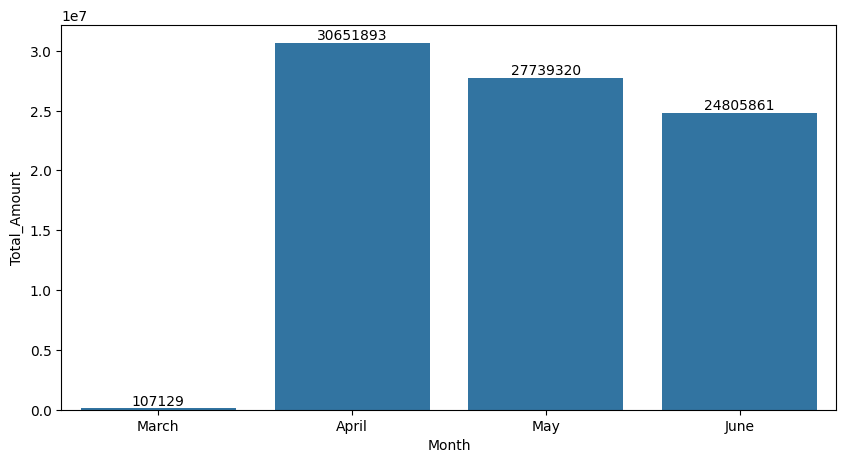

In [5]:
order = ["March", "April", "May", "June"]
monthly_trend = df.groupby("Month")["Amount"].sum().reset_index(name="Total_Amount")
plt.figure(figsize=(10,5))
ax = sns.barplot(data=monthly_trend, x="Month", y="Total_Amount", order=order)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.show()    

Revenue by CATEGORY

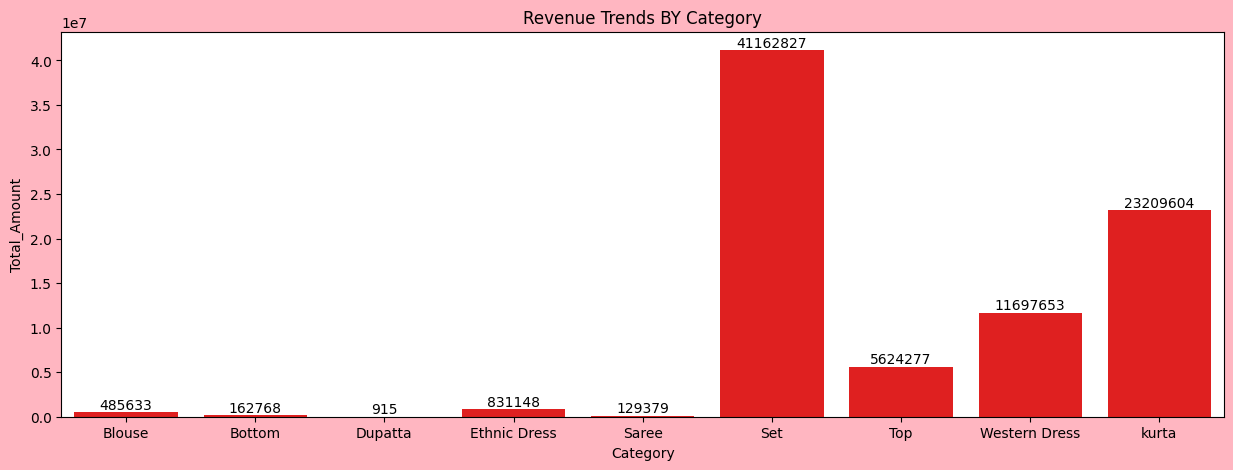

In [6]:
category_revenue = df.groupby("Category")["Amount"].sum().reset_index(name="Total_Amount")
plt.figure(figsize=(15, 5), facecolor="lightpink")
ax = sns.barplot(data=category_revenue, x="Category", y="Total_Amount", color="red")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.title("Revenue Trends BY Category")
plt.show()    

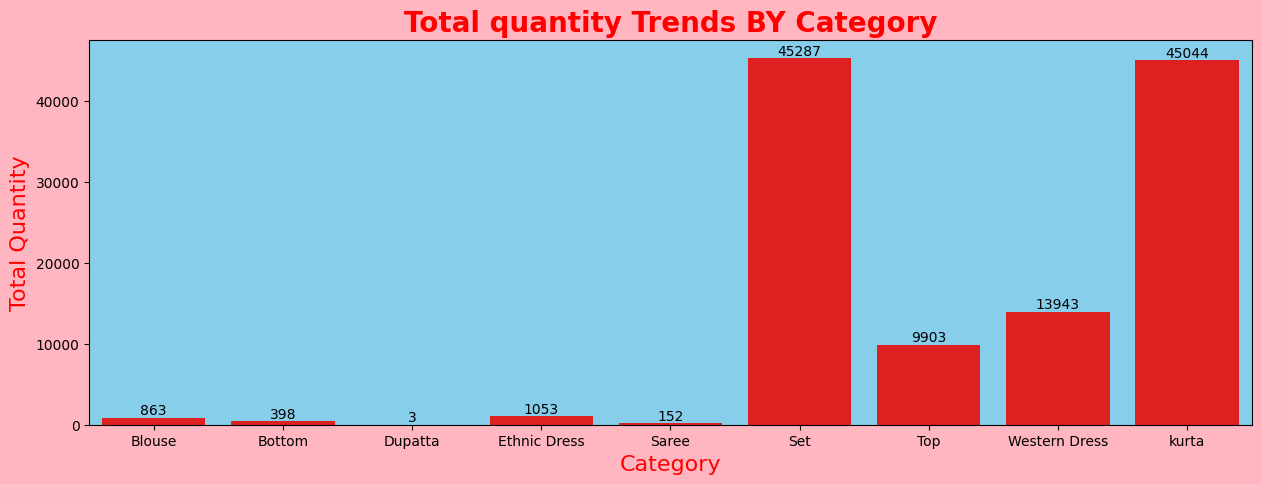

In [7]:
category_Quantity = df.groupby("Category")["Qty"].sum().reset_index(name="Total_Quantity")
plt.figure(figsize=(15, 5), facecolor="lightpink")
ax = sns.barplot(data=category_Quantity, x="Category", y="Total_Quantity", color="red")
ax.set_facecolor("skyblue")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.title("Total quantity Trends BY Category", fontsize=20, fontweight="bold", color = "red")
plt.xlabel("Category", fontsize=16, fontweight = "roman", color="red")
plt.ylabel("Total Quantity", fontsize = 16, fontweight = "roman", color = "red")
plt.show()

Top _selling Sizes

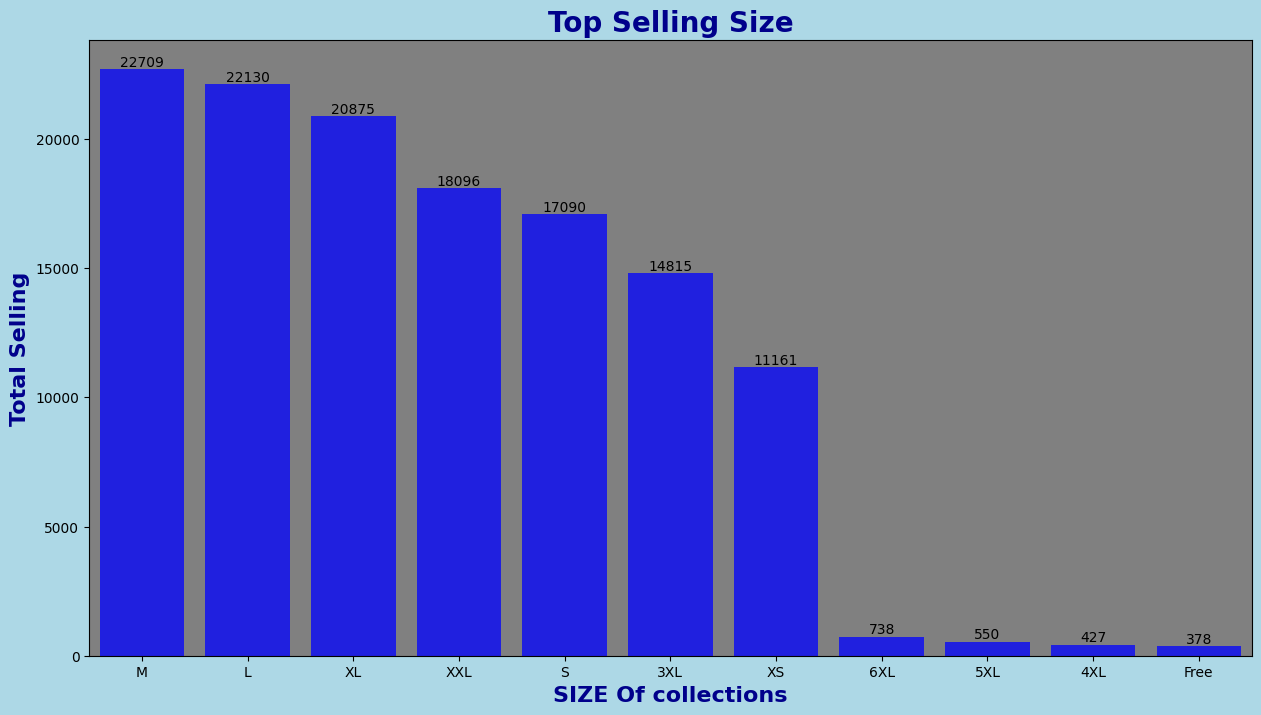

In [8]:
top_size_selling = df.groupby("Size").size().reset_index(name="Total Selling").sort_values(by="Total Selling",ascending=False)
plt.figure(figsize=(15, 8),facecolor="lightblue")
ax = sns.barplot(data=top_size_selling, x="Size", y="Total Selling", color="blue")
ax.set_facecolor("gray")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.title("Top Selling Size", fontsize=20, fontweight="bold", color="darkblue")
plt.xlabel("SIZE Of collections", fontsize=16, fontweight="bold", color="darkblue")
plt.ylabel("Total Selling", fontsize=16, fontweight="bold", color="darkblue")
plt.show()

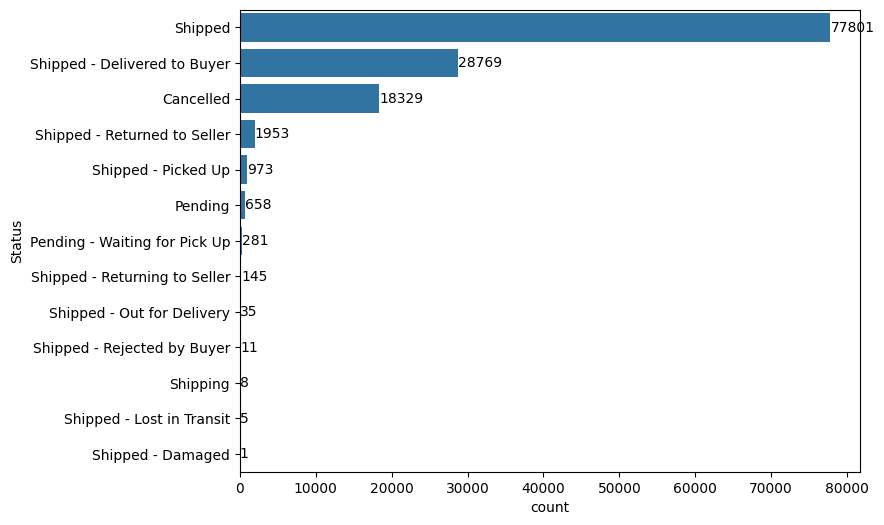

In [9]:

plt.figure(figsize=(8,6))
ax = sns.countplot(data=df, y="Status", order=df["Status"].value_counts().index)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.show()

FULFILMENT METHOD

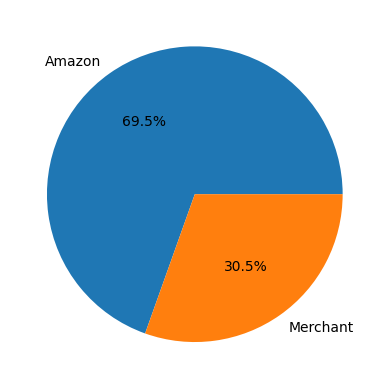

In [10]:
FULFILMENT = df["Fulfilment"].value_counts()
FULFILMENT.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.show()

states By revenue

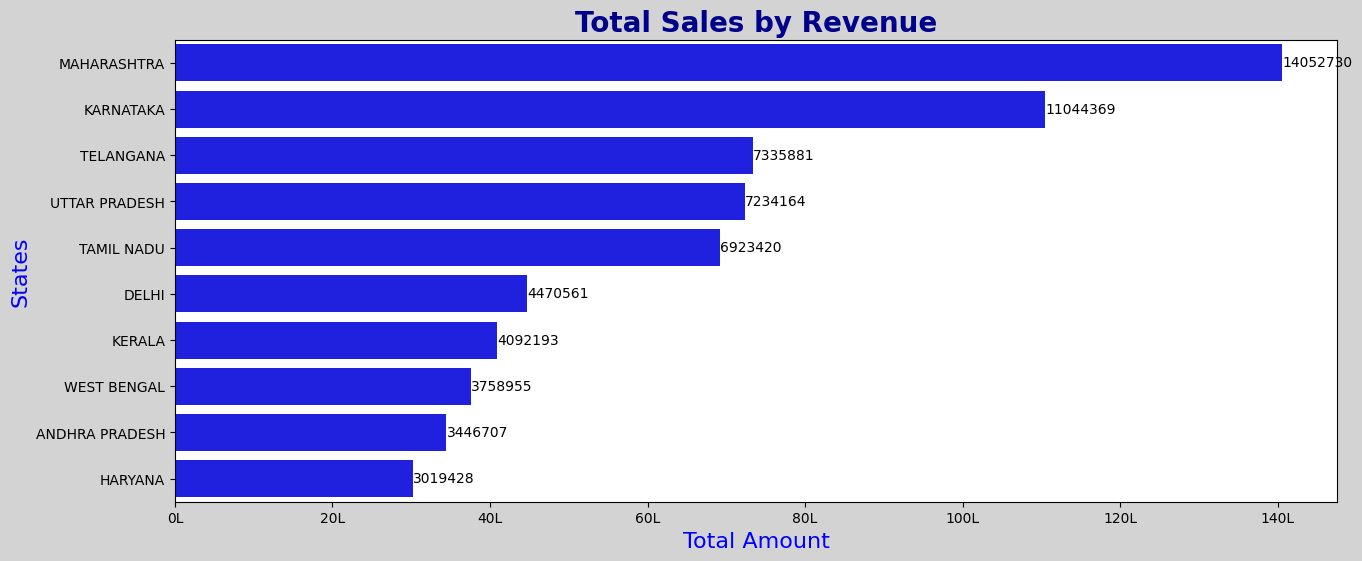

In [20]:
state_revenue = (df.groupby("ship-state")["Amount"].sum().nlargest(10).reset_index(name="Total Amount"))
plt.figure(figsize=(15,6), facecolor="lightgray")
ax= sns.barplot(data=state_revenue, x="Total Amount", y="ship-state", color="blue")
for contain in ax.containers:
    ax.bar_label(contain, fmt="%.0f")
plt.title("Total Sales by Revenue", fontsize=20, fontweight="bold", color="darkblue")
plt.xlabel("Total Amount", fontsize=16, fontweight="roman", color="blue")
plt.ylabel("States", fontsize=16, fontweight="roman", color="blue")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos:f"{x/100000:.0f}L"))
plt.show()    

TOP 10 CITIES REVENUE

In [12]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'Amount', 'ship-city', 'ship-state', 'B2B',
       'Year', 'Month', 'Day', 'Quarter'],
      dtype='object')

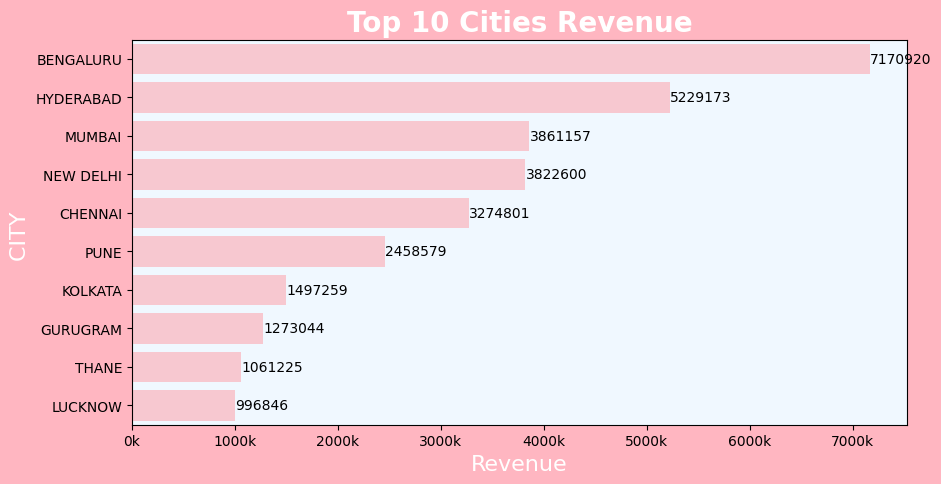

In [17]:
TOP_CITIES = df.groupby("ship-city")["Amount"].sum().nlargest(10).reset_index(name="Total Revenue")
plt.figure(figsize=(10,5), facecolor="lightpink")
ax = sns.barplot(data=TOP_CITIES, x="Total Revenue", y="ship-city", color="pink")
ax.set_facecolor("aliceblue")
plt.title("Top 10 Cities Revenue", fontsize=20, fontweight="bold", color="white")
plt.xlabel("Revenue", fontsize=16, fontweight="roman", color="white")
plt.ylabel("CITY ", fontsize=16, fontweight="roman", color="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos:f"{x/1000:.0f}k"))    
plt.show()

COURIER STATUS ANALYSIS

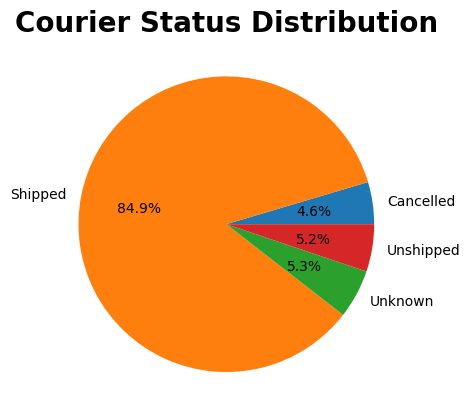

In [30]:
Courier_status = df.groupby("Courier Status").size()
Courier_status.plot(kind="pie", autopct="%1.1f%%")
plt.title("Courier Status Distribution", fontsize=20, fontweight="bold")
plt.ylabel("")
plt.show()

weakly revenue analysis

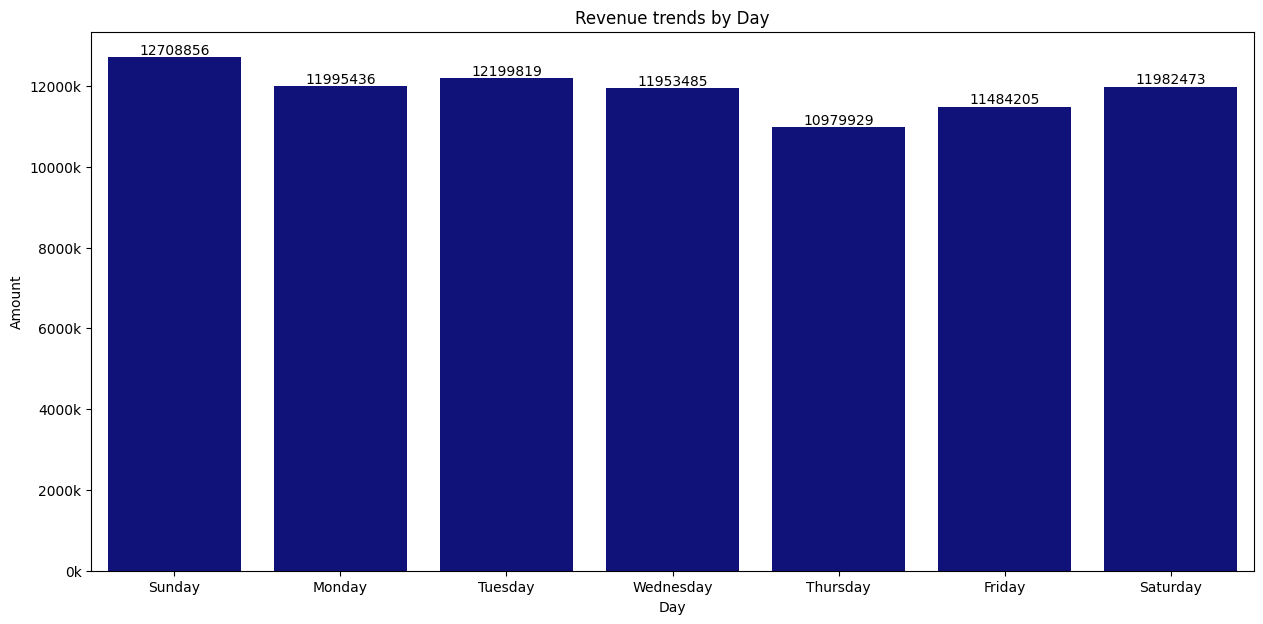

In [39]:
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
day_by_revenue = df.groupby("Day")["Amount"].sum(). reset_index(name="Total Revenue")
plt.figure(figsize=(15, 7))
ax = sns.barplot(data=day_by_revenue, x="Day", y="Total Revenue", order=day_order, color="darkblue")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f}k"))
plt.title("Revenue trends by Day")
plt.xlabel("Day")
plt.ylabel("Amount")
plt.show()


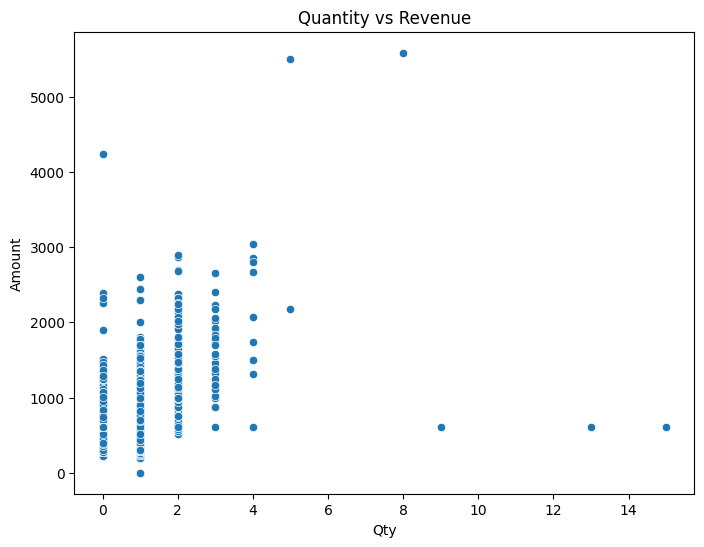

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="Qty",
                y="Amount")

plt.title("Quantity vs Revenue")

plt.show()

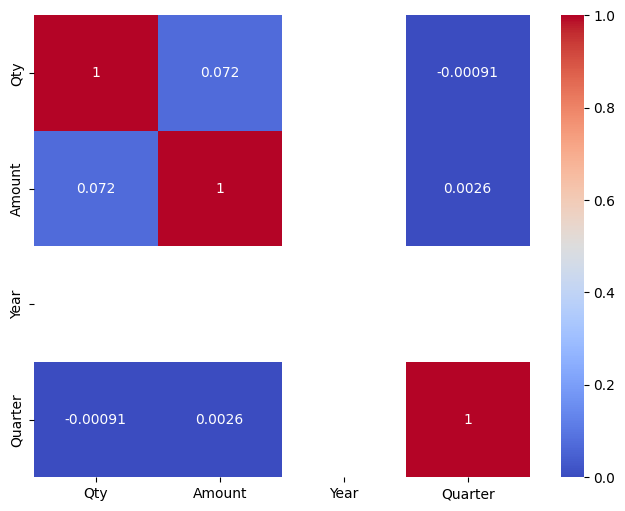

In [37]:
numeric = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

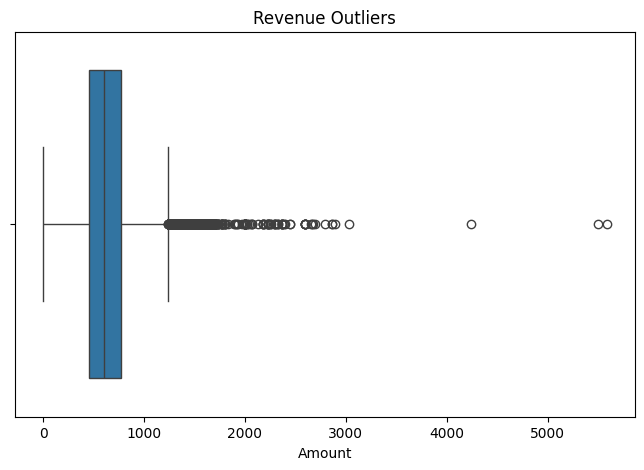

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Amount"])

plt.title("Revenue Outliers")

plt.show()